### librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

### data

In [47]:
DATA_PREDICTIONS_PATH = "data\\predictions_1993-2025_6_meses_4p_rol.csv"

def load_csv(path):
    return pd.read_csv(path)

In [48]:
df_predictions = load_csv(DATA_PREDICTIONS_PATH)[["date", "pred_cop_usd", "true_cop_usd", "error_abs"]]

# 1. Asegurar formato fecha
df_predictions["date"] = pd.to_datetime(df_predictions["date"])

# 2. Ordenar cronológicamente (esto evita las líneas cruzadas en los plots)
df_predictions = df_predictions.sort_values("date").reset_index(drop=True)

# 3. Calcular el error
df_predictions["error"] = df_predictions["pred_cop_usd"] - df_predictions["true_cop_usd"]

df_predictions.head(10)

,date,pred_cop_usd,true_cop_usd,error_abs,error
0,1995-01-02,829.31770,831.27,1.952332,-1.95230
1,1995-01-03,831.10380,833.18,2.076172,-2.07620
2,1995-01-04,830.71375,835.38,4.666260,-4.66625
3,1995-01-05,829.52780,838.33,8.802246,-8.80220
4,1995-01-06,828.57886,838.87,10.291138,-10.29114
5,1995-01-09,830.03760,836.50,6.462402,-6.46240
6,1995-01-10,831.18665,837.07,5.883362,-5.88335
7,1995-01-11,829.76245,840.36,10.597534,-10.59755
8,1995-01-12,831.45470,843.69,12.235291,-12.23530
9,1995-01-13,828.63214,841.52,12.887878,-12.88786


### plot-time series

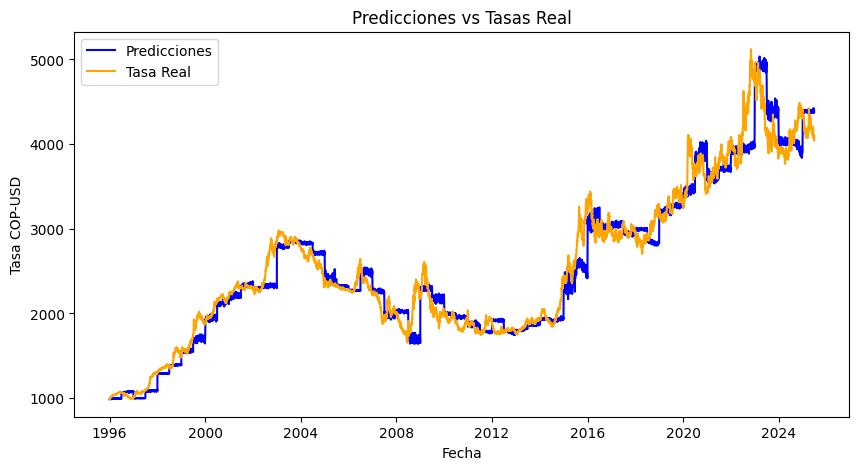

In [49]:
data_1994_2025 = df_predictions[df_predictions["date"] >= "1996-01-01"].copy()
plt.figure(figsize=(10, 5))
plt.plot(data_1994_2025["date"], data_1994_2025["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_1994_2025["date"], data_1994_2025["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

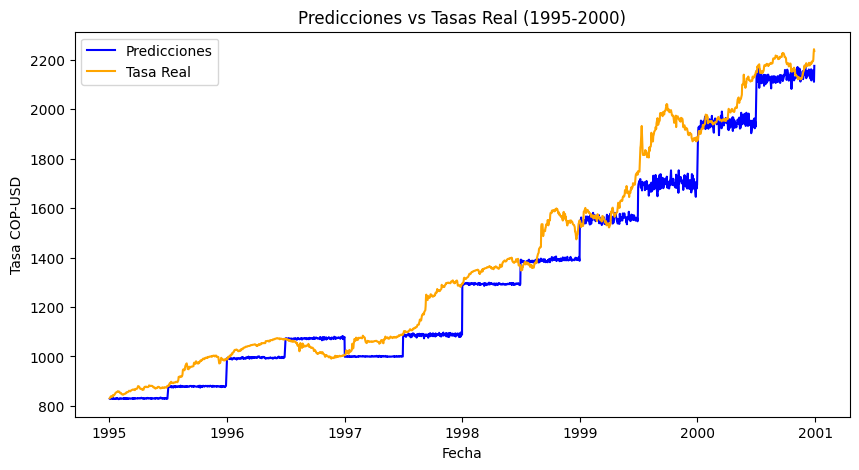

In [50]:
data_1995_2000 = df_predictions[(df_predictions["date"] >= "1995-01-01") & (df_predictions["date"] < "2001-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_1995_2000["date"], data_1995_2000["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_1995_2000["date"], data_1995_2000["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (1995-2000)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

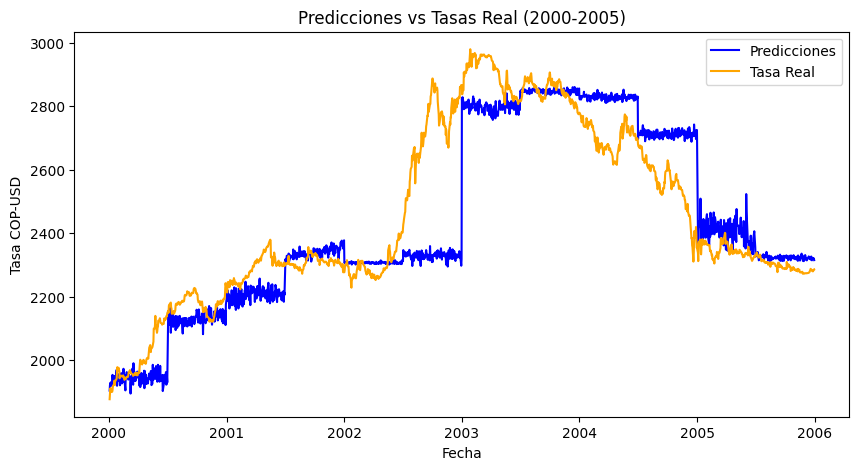

In [51]:
data_2000_2005 = df_predictions[(df_predictions["date"] >= "2000-01-01") & (df_predictions["date"] < "2006-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_2000_2005["date"], data_2000_2005["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_2000_2005["date"], data_2000_2005["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (2000-2005)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

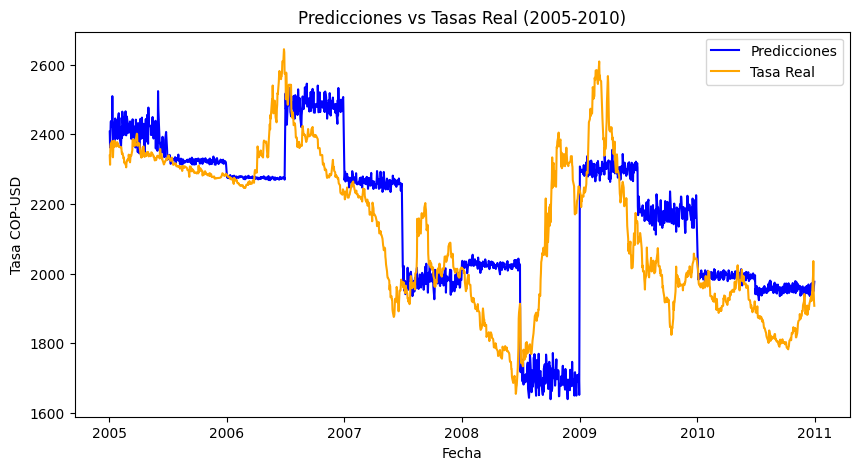

In [52]:
data_2005_2010 = df_predictions[(df_predictions["date"] >= "2005-01-01") & (df_predictions["date"] < "2011-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_2005_2010["date"], data_2005_2010["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_2005_2010["date"], data_2005_2010["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (2005-2010)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

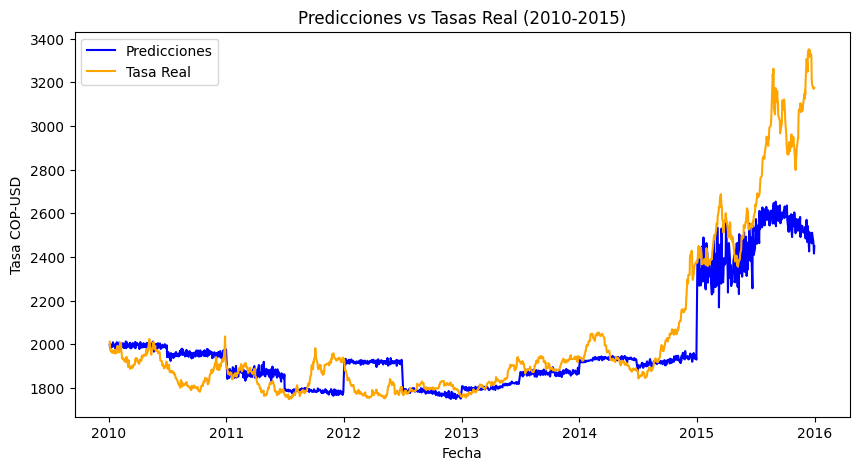

In [53]:
data_2010_2015 = df_predictions[(df_predictions["date"] >= "2010-01-01") & (df_predictions["date"] < "2016-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_2010_2015["date"], data_2010_2015["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_2010_2015["date"], data_2010_2015["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (2010-2015)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

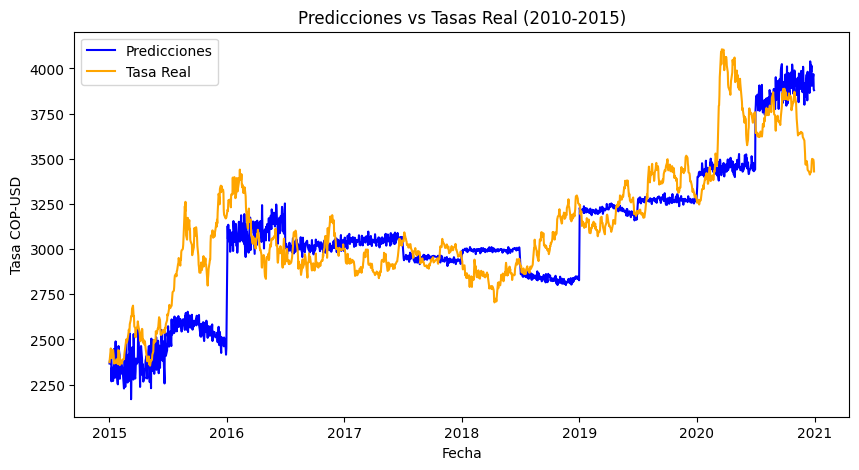

In [54]:
data_2015_2020 = df_predictions[(df_predictions["date"] >= "2015-01-01") & (df_predictions["date"] < "2021-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_2015_2020["date"], data_2015_2020["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_2015_2020["date"], data_2015_2020["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (2010-2015)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

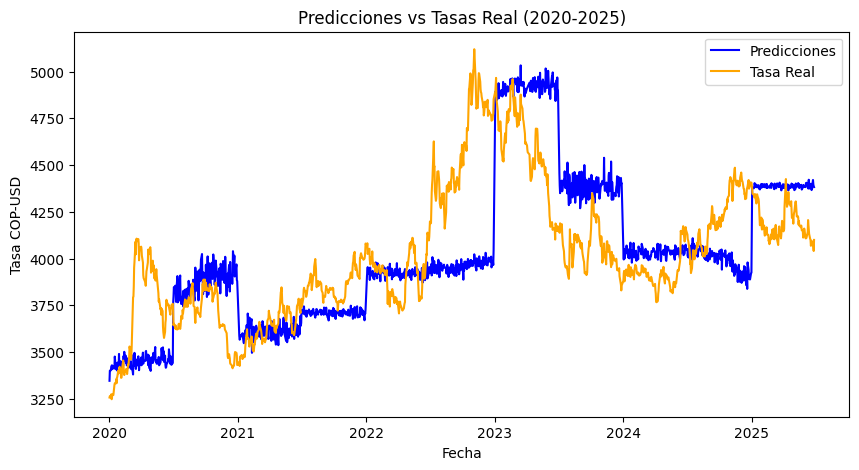

In [55]:
data_2020_2025 = df_predictions[(df_predictions["date"] >= "2020-01-01") & (df_predictions["date"] < "2026-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_2020_2025["date"], data_2020_2025["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_2020_2025["date"], data_2020_2025["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (2020-2025)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

### Error Analisis

#### Sobre o Sube Estimacion

In [56]:
mean_error = df_predictions["error"].mean()
dest_error = df_predictions["error"].std()
median_error = df_predictions["error"].median()

mean_abs_error = df_predictions["error_abs"].mean()
dest_abs_error = df_predictions["error_abs"].std()
median_abs_error = df_predictions["error_abs"].median()

print(f"--------Error--------")
print(f"Mean error: {mean_error}")
print(f"Std Desv error: {dest_error}")
print(f"Median error: {median_error}")

print(f"--------Absolute error--------")
print(f"Mean abs error: {mean_abs_error}")
print(f"Std Desv abs error: {dest_abs_error}")
print(f"Median abs error: {median_abs_error}")

print(f"--------Estimation--------")
over = np.mean(df_predictions["error"] > 0)
under = np.mean(df_predictions["error"] < 0)

print(f"Overestimation: {over:.2%}")
print(f"Underestimation: {under:.2%}")

--------Error--------
Mean error: -28.188341453201975
Std Desv error: 198.91167709343551
Median error: -11.363000000000056
--------Absolute error--------
Mean abs error: 136.09002652015698
Std Desv abs error: 147.77565898158704
Median abs error: 88.19003000000001
--------Estimation--------
Overestimation: 46.85%
Underestimation: 53.15%


#### Distribucion del error:

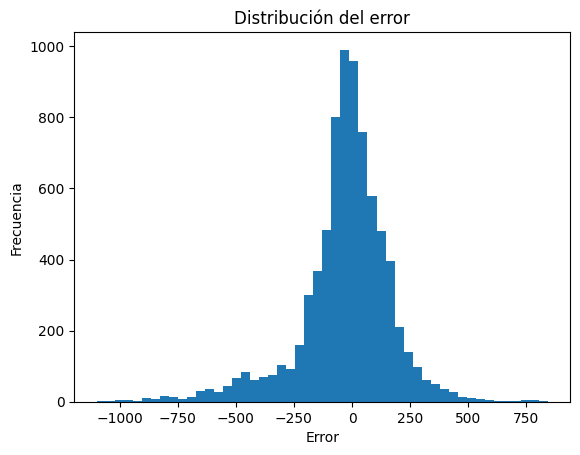

In [57]:
plt.figure()
plt.hist(df_predictions["error"], bins=50)
plt.title("Distribución del error")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

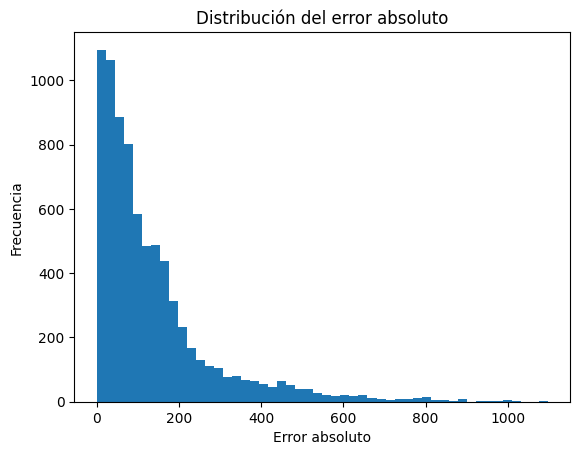

In [58]:
plt.figure()
plt.hist(df_predictions["error_abs"], bins=50)
plt.title("Distribución del error absoluto")
plt.xlabel("Error absoluto")
plt.ylabel("Frecuencia")
plt.show()

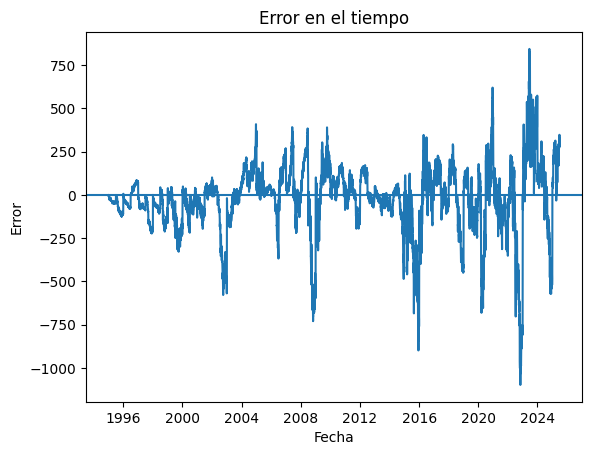

In [59]:
plt.figure()
plt.plot(df_predictions["date"], df_predictions["error"])
plt.axhline(0)
plt.title("Error en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Error")
plt.show()

In [60]:
errors = df_predictions["error"]

mean = errors.mean()
std = errors.std(ddof=1)
n = len(errors)

# intervalo de confianza del error medio
ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=std/np.sqrt(n))

print(f"IC 95% del error medio: {ci}")

# percentiles (más robusto que asumir normalidad)
p_low = np.percentile(errors, 2.5)
p_high = np.percentile(errors, 97.5)

print(f"Intervalo empírico 95% del error: [{p_low}, {p_high}]")

p_low_abs = np.percentile(df_predictions["error_abs"], 2.5)
p_high_abs = np.percentile(df_predictions["error_abs"], 97.5)

print(f"Intervalo empírico 95% del error absoluto: [{p_low_abs}, {p_high_abs}]")

IC 95% del error medio: (np.float64(-32.62786853708273), np.float64(-23.748814369321217))
Intervalo empírico 95% del error: [-537.3763375000001, 321.9781125000002]
Intervalo empírico 95% del error absoluto: [4.244467125, 563.8932475000003]


#### plot Resampling:

In [61]:
df_predictions_time_series = df_predictions.set_index("date")

In [62]:
def analyze_errors(df, label=""):
    import numpy as np
    import matplotlib.pyplot as plt
    
    df = df.copy()
    
    df["error"] = df["pred_cop_usd"] - df["true_cop_usd"]
    df["error_abs"] = np.abs(df["error"])
    
    # 🔥 CLAVE: eliminar NaNs
    errors = df["error"].dropna()
    errors_abs = df["error_abs"].dropna()
    
    print(f"\n--- {label} ---")
    
    print("Mean error:", errors.mean())
    print("Std error:", errors.std())
    
    print("IC 95% error:",
          np.percentile(errors, [2.5, 97.5]))
    
    print("IC 95% error abs:",
          np.percentile(errors_abs, [2.5, 97.5]))
    
    # plots
    plt.figure()
    plt.hist(errors, bins=50)
    plt.title(f"Error distribution {label}")
    plt.show()
    
    plt.figure()
    plt.hist(errors_abs, bins=50)
    plt.title(f"Absolute error distribution {label}")
    plt.show()


--- Weekly ---
Mean error: -27.563427596855348
Std error: 198.32029864096162
IC 95% error: [-525.02991938  329.60932917]
IC 95% error abs: [  4.573509 560.997869]


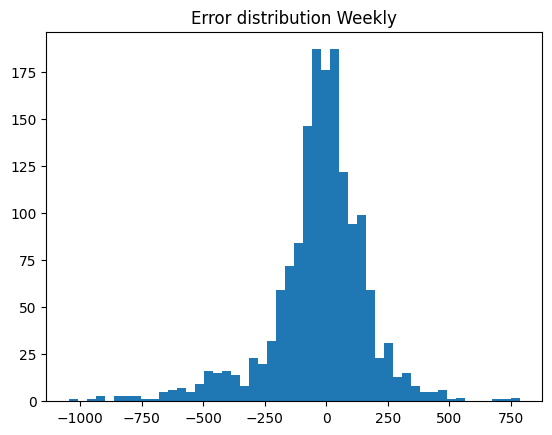

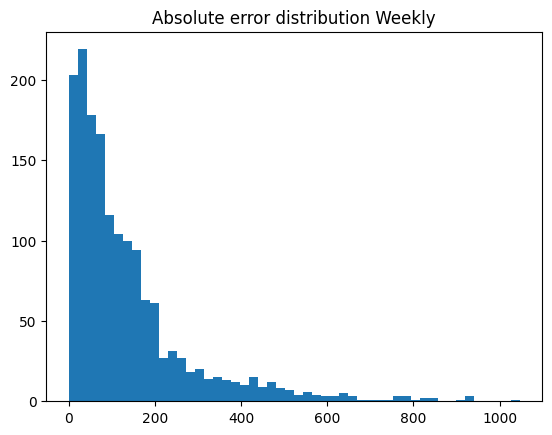

In [63]:
df_weekly = df_predictions_time_series.resample("W").mean()
analyze_errors(df_weekly, "Weekly")


--- Mothly ---
Mean error: -27.563427596855348
Std error: 198.32029864096162
IC 95% error: [-525.02991938  329.60932917]
IC 95% error abs: [  4.573509 560.997869]


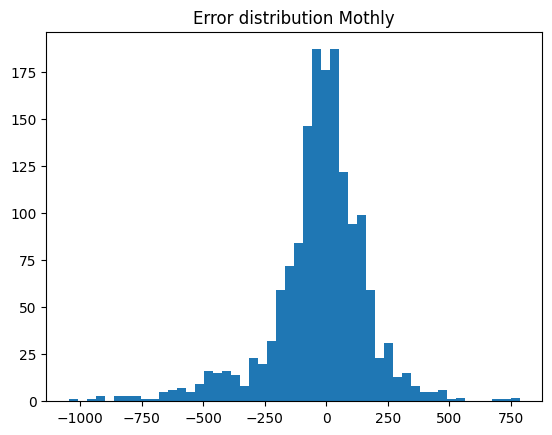

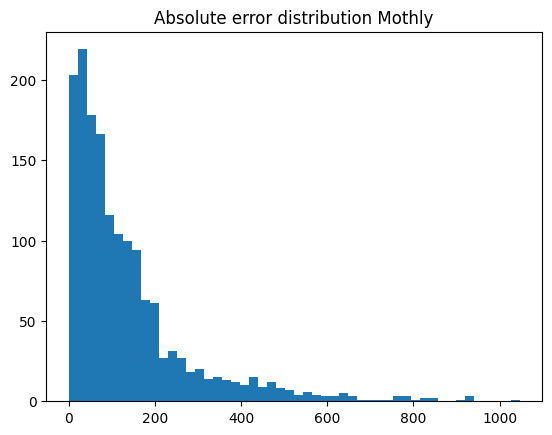

In [64]:
df_mothly = df_predictions_time_series.resample("ME").mean()
analyze_errors(df_weekly, "Mothly")


--- Yearly ---
Mean error: -27.563427596855348
Std error: 198.32029864096162
IC 95% error: [-525.02991938  329.60932917]
IC 95% error abs: [  4.573509 560.997869]


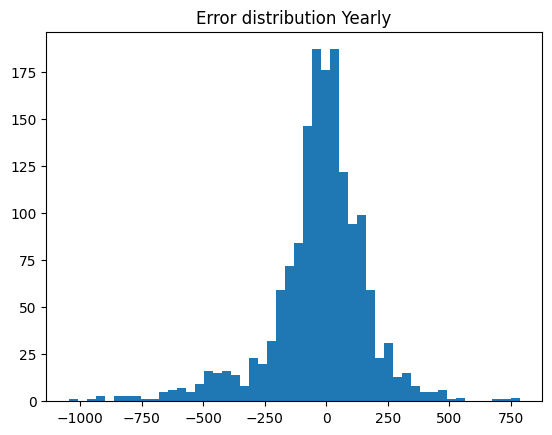

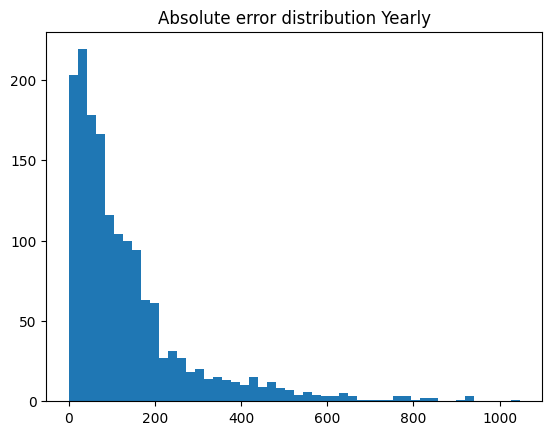

In [65]:
df_yearly = df_predictions_time_series.resample("YE").mean()
analyze_errors(df_weekly, "Yearly")